In [1]:
import pandas as pd

from Pipeline.Global.PlottingData import PlottingData

In [2]:
filePath = '../../Storage/Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [3]:
df.isnull().values.any()

np.False_

In [4]:
categorical_vars = [
    'Gallstone Status', 'Gender', 'Comorbidity',
    'Coronary Artery Disease (CAD)', 'Hypothyroidism',
    'Hyperlipidemia', 'Diabetes Mellitus (DM)', 'Hepatic Fat Accumulation (HFA)'
]
continuous_vars = [col for col in df.columns if col not in categorical_vars]
summary_list = []

for col in categorical_vars:
    try:
        temp_col = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        temp_col = df[col]

    counts = temp_col.value_counts(dropna=False).sort_index()
    percentages = temp_col.value_counts(normalize=True, dropna=False).sort_index() * 100

    n_list = [int(c) for c in counts.values]
    pct_list = [f"({p:.1f}%)" for p in percentages.values]

    clean_categories = [int(idx) if pd.notna(idx) and isinstance(idx, (int, float)) else ('Missing' if pd.isna(idx) else idx) for idx in counts.index]

    feature_names = [col] + [''] * (len(counts) - 1)

    temp_df = pd.DataFrame({
        'Characteristic': feature_names,
        'Category': clean_categories,
        'N': n_list,
        '(%)': pct_list
    })
    summary_list.append(temp_df)

In [5]:
cat_table = pd.concat(summary_list, ignore_index=True)
cat_table

,Characteristic,Category,N,(%)
0,Gallstone Status,0,161,(50.5%)
1,,1,158,(49.5%)
2,Gender,0,162,(50.8%)
3,,1,157,(49.2%)
4,Comorbidity,0,217,(68.0%)
5,,1,99,(31.0%)
6,,2,1,(0.3%)
7,,3,2,(0.6%)
8,Coronary Artery Disease (CAD),0,307,(96.2%)
9,,1,12,(3.8%)


In [6]:
cont_table = df[continuous_vars]
stat_df = cont_table.describe()

In [7]:
one_decimal = ['Age', 'Height','Weight', 'Body Mass Index (BMI)','Total Body Water (TBW)', 'Extracellular Water (ECW)',
               'Intracellular Water (ICW)','Bone Mass (BM)', 'Muscle Mass (MM)','Total Fat Content (TFC)','Visceral Muscle Area (VMA) (Kg)','Visceral Fat Rating (VFR)' ,'Glucose', 'Total Cholesterol (TC)',
       'Low Density Lipoprotein (LDL)', 'High Density Lipoprotein (HDL)',
       'Triglyceride', 'Aspartat Aminotransferaz (AST)','Alanin Aminotransferaz (ALT)', 'Alkaline Phosphatase (ALP)',]
two_decimal = ['Extracellular Fluid/Total Body Water (ECF/TBW)','Total Body Fat Ratio (TBFR) (%)','Lean Mass (LM) (%)','Body Protein Content (Protein) (%)','Obesity (%)','Visceral Fat Area (VFA)','Creatinine', 'Glomerular Filtration Rate (GFR)',
       'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']

formatted_stat_df = stat_df.copy().astype(object)

for col in stat_df.columns:
    formatted_stat_df.loc['count', col] = int(stat_df.loc['count', col])
    other_rows = stat_df.index != 'count'

    if col in one_decimal:
        formatted_stat_df.loc[other_rows, col] = stat_df.loc[other_rows, col].round(1)
    elif col in two_decimal:
        formatted_stat_df.loc[other_rows, col] = stat_df.loc[other_rows, col].round(2)

In [8]:
formatted_stat_df.transpose()

,count,mean,std,min,25%,50%,75%,max
Age,319,48.1,12.1,20.0,38.5,49.0,56.0,96.0
Height,319,167.2,10.1,145.0,159.5,168.0,175.0,191.0
Weight,319,80.6,15.7,42.9,69.6,78.8,91.2,143.5
Body Mass Index (BMI),319,28.9,5.3,17.4,25.2,28.3,31.8,49.7
Total Body Water (TBW),319,40.6,7.9,13.0,34.2,39.8,47.0,66.2
Extracellular Water (ECW),319,17.1,3.2,9.0,14.8,17.1,19.4,27.8
Intracellular Water (ICW),319,23.6,5.3,13.8,19.3,23.0,27.6,57.1
Extracellular Fluid/Total Body Water (ECF/TBW),319,42.21,3.24,29.23,40.08,42.0,44.0,52.0
Total Body Fat Ratio (TBFR) (%),319,28.27,8.44,6.3,22.02,27.82,34.81,50.92
Lean Mass (LM) (%),319,71.64,8.44,48.99,65.17,72.11,77.85,93.67


[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Data Figure\Anthropometric_Distribution_.png


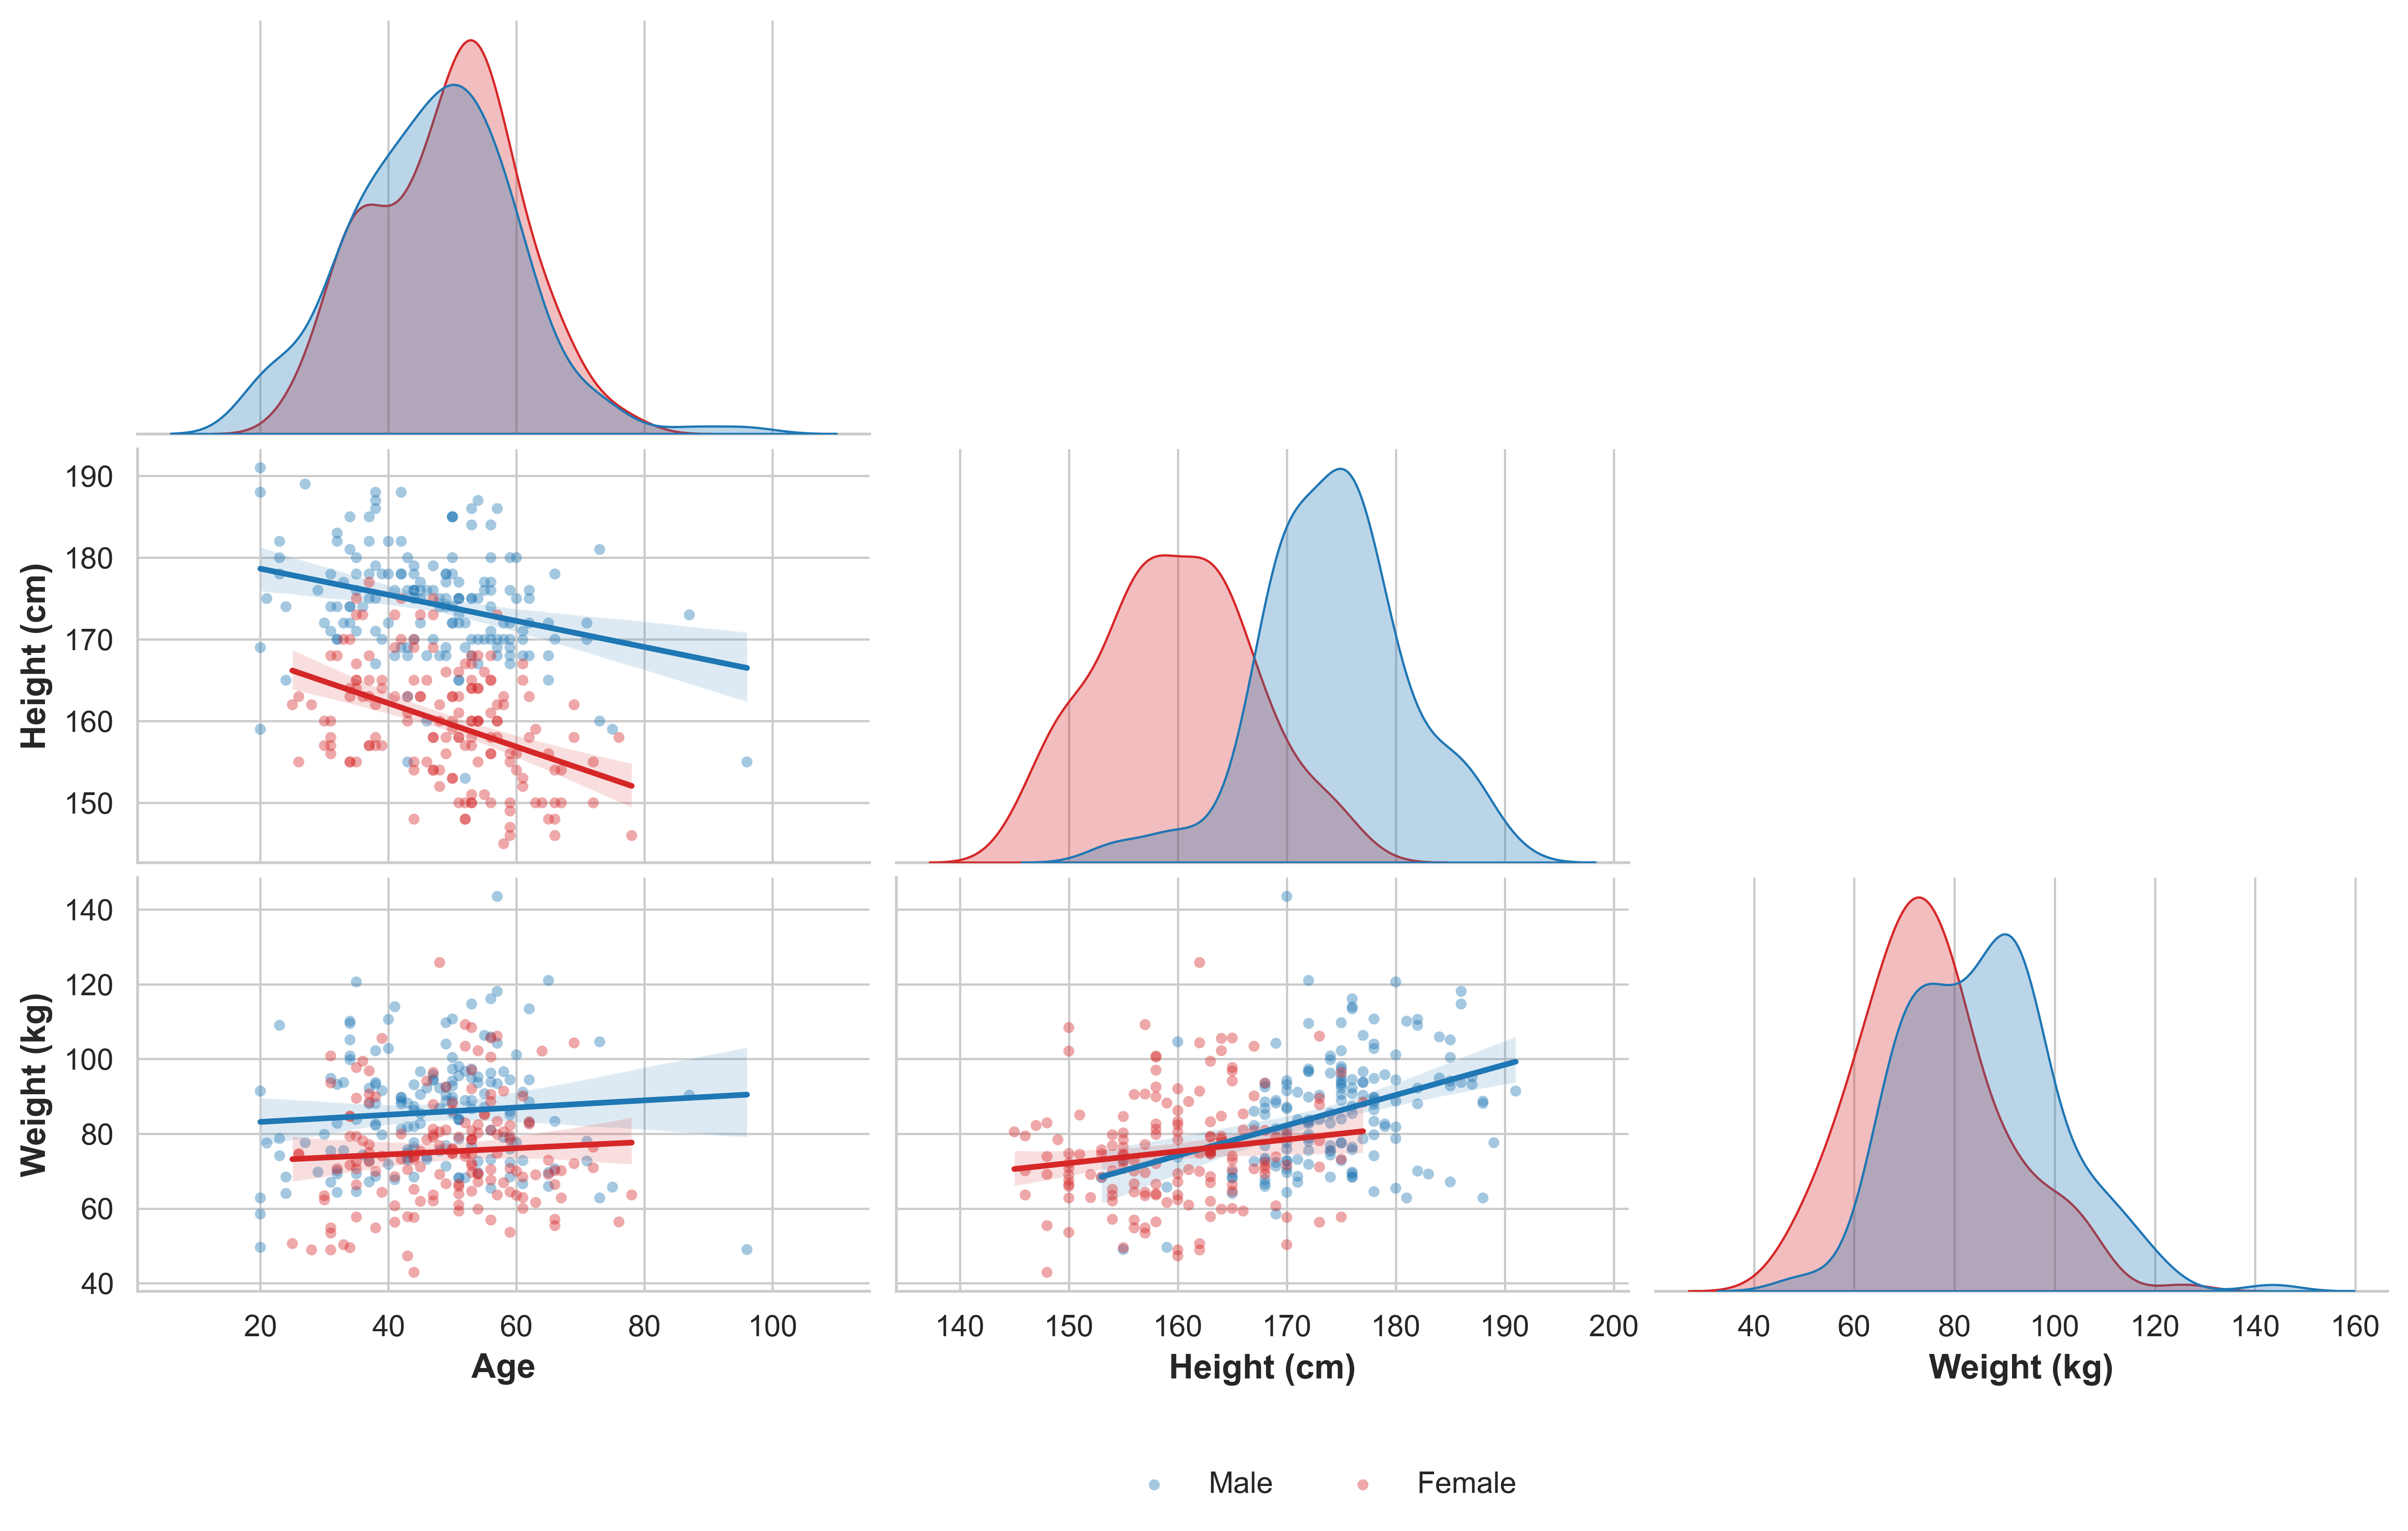

In [9]:
# GROUP 1: DEMOGRAPHIC & ANTHROPOMETRIC BASELINES
# Source: Electronic Health Records (EHR) and Standard Physical Measurement.
df_demographic = df[[
    'Age',                    # Range: 20-96 years
    'Gender',                 # Binary: 0=Male, 1=Female
    'Height',                 # Measured barefoot (cm)
    'Weight'                  # Measured with thin clothing (kg)
]].copy()
PlottingData.plot_anthropometric_distribution(df_demographic, title_on=False,is_final_record=True)

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Data Figure\Distribution_of_Comorbidity_Scores_.png


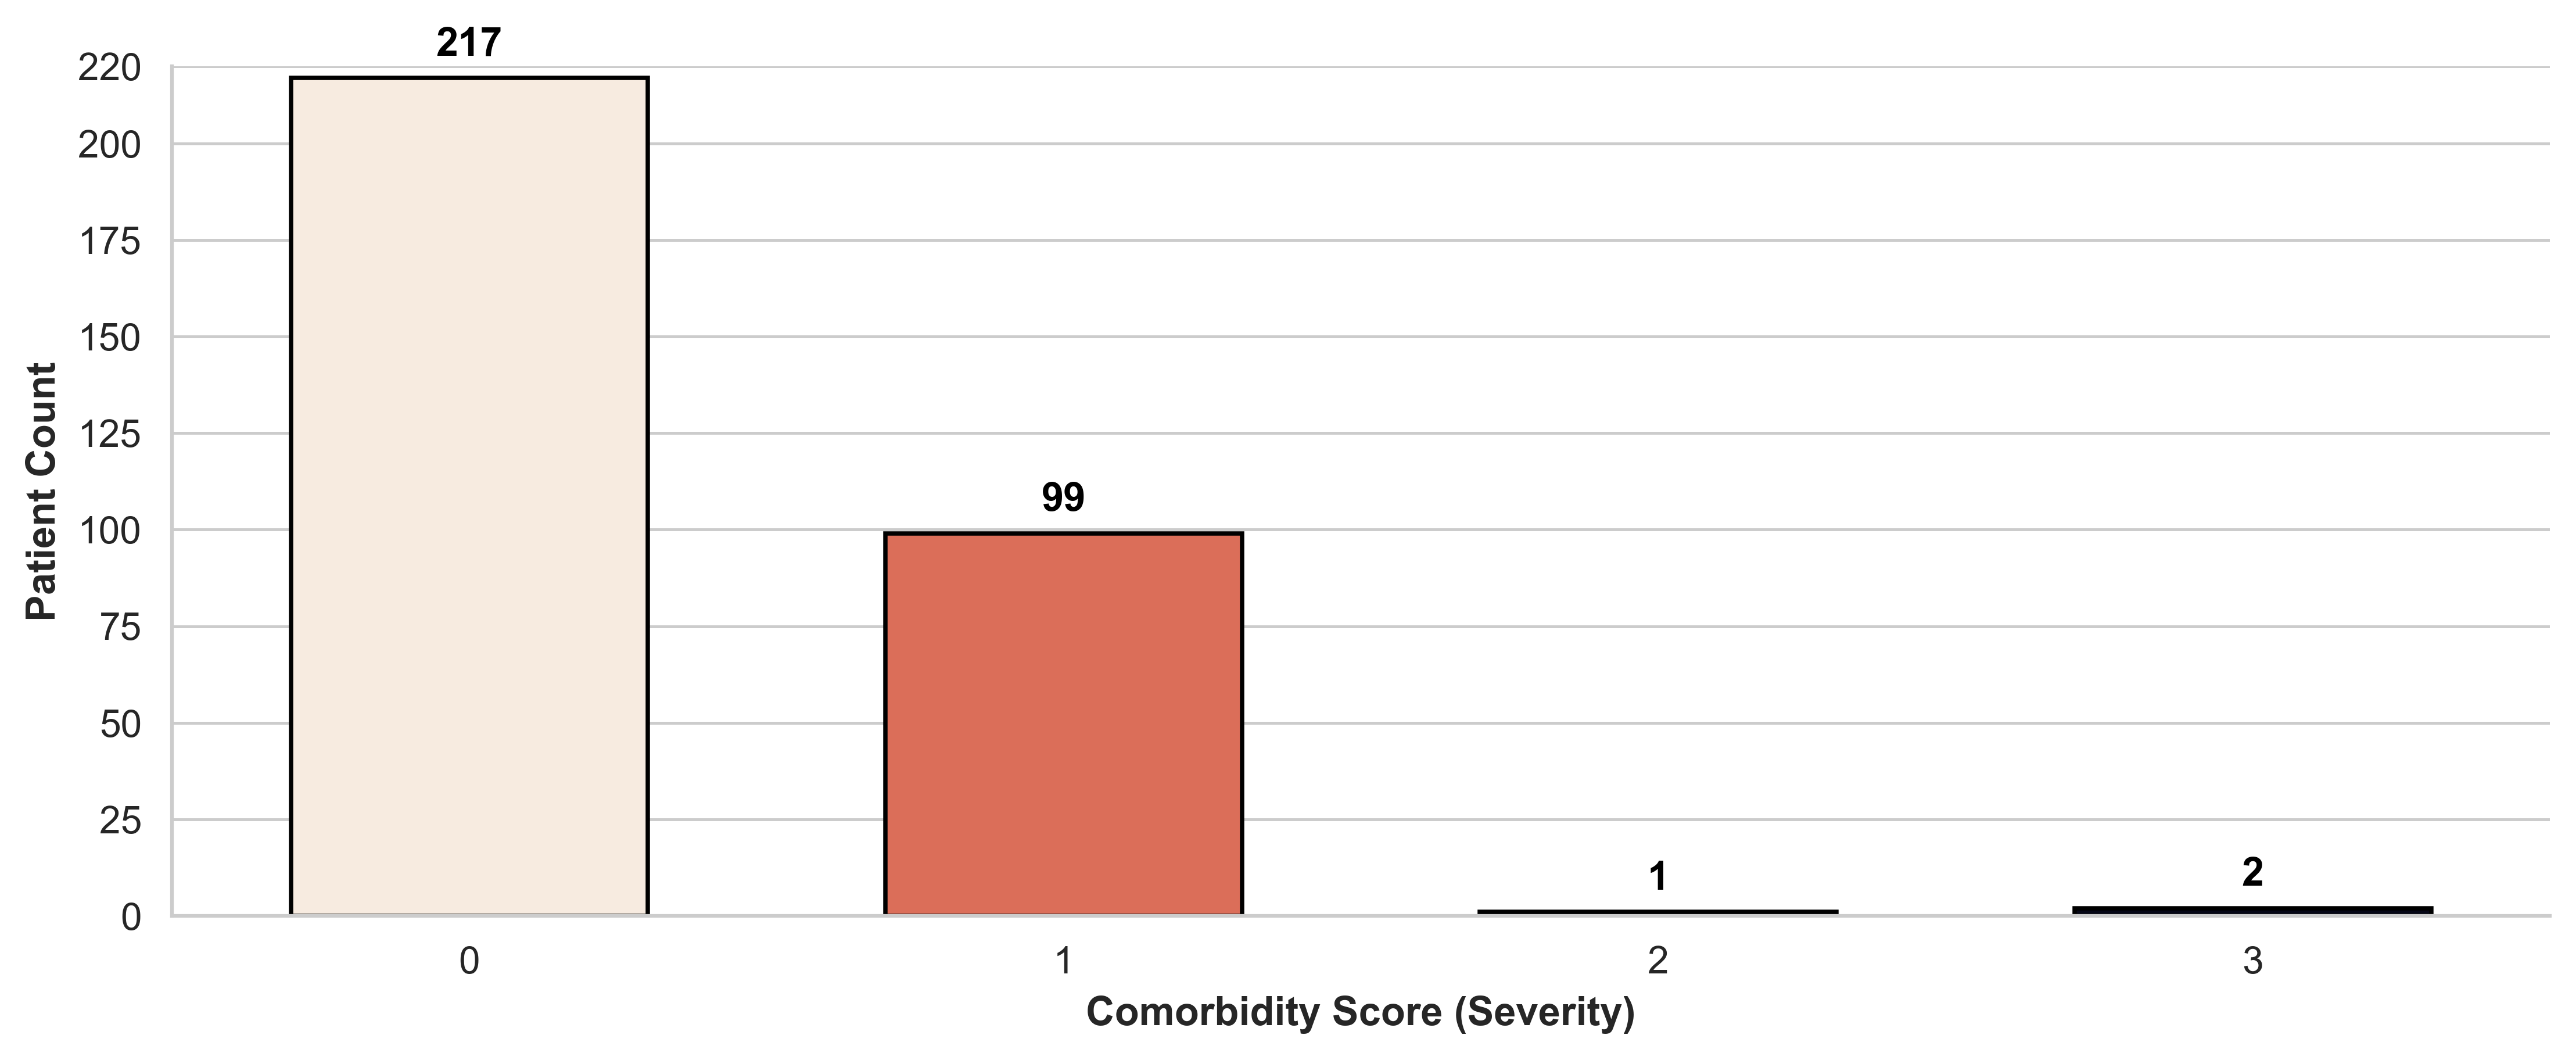

In [10]:
# GROUP 2A: COMORBIDITY SCORE (ORDINAL)
# Source: Medical History Review.
# [cite_start]DATASET ERROR: The paper describes 'Comorbidity' as a binary variable[cite: 68], but the dataset contains ordinal values (0-3), likely indicating a severity score or count.
df_comorbidity_score = df[[
    'Comorbidity'             # Ordinal Variable (Severity/Count)
]].copy()
PlottingData.plot_comorbidity_distribution(df_comorbidity_score,title_on=False,is_final_record=True)

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Data Figure\Prevalence_of_Clinical_Conditions_Cohort_Profile_.png


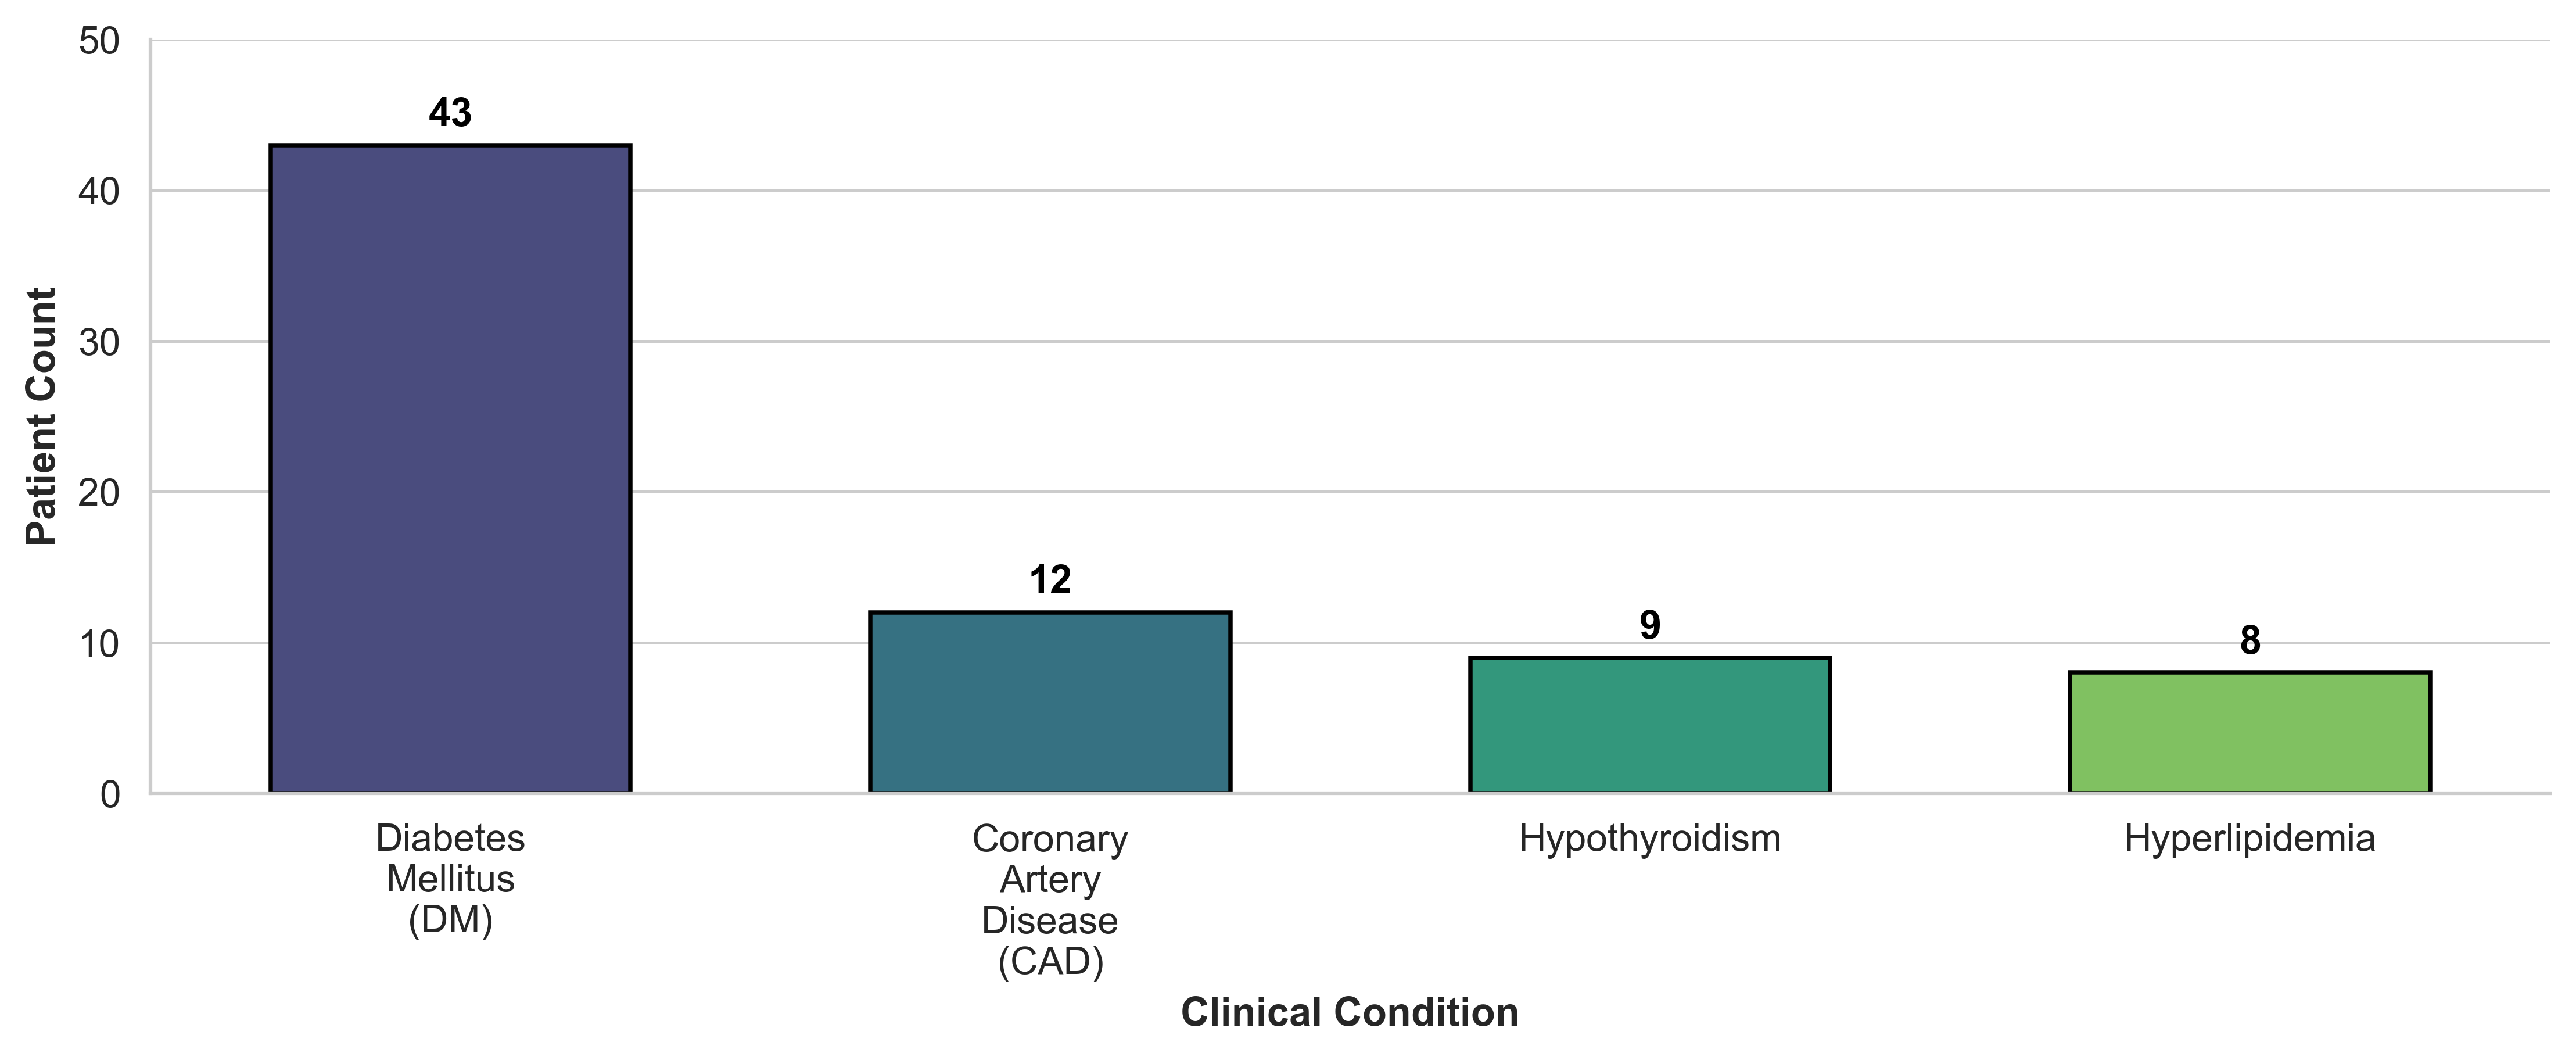

In [11]:
# GROUP 2B: CLINICAL CONDITIONS (BINARY)
# Source: Medical History Flags.
# DATASET ERROR: The CSV header 'Coronary Artery Disease (CAD)' contradicts the paper, which lists 'Hypertension' as the feature.
df_clinical_conditions = df[[
    'Coronary Artery Disease (CAD)', # Storage lists CAD; Paper lists Hypertension
    'Hypothyroidism',                # Diagnosed Thyroid deficiency
    'Hyperlipidemia',                # High lipid levels
    'Diabetes Mellitus (DM)'         # Diabetic status
]].copy()
PlottingData.plot_clinical_conditions_prevalence(df_clinical_conditions,title_on=False,is_final_record=True)

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Data Figure\Hepatic_Fat_Accumulation_HFA_Severity_.png


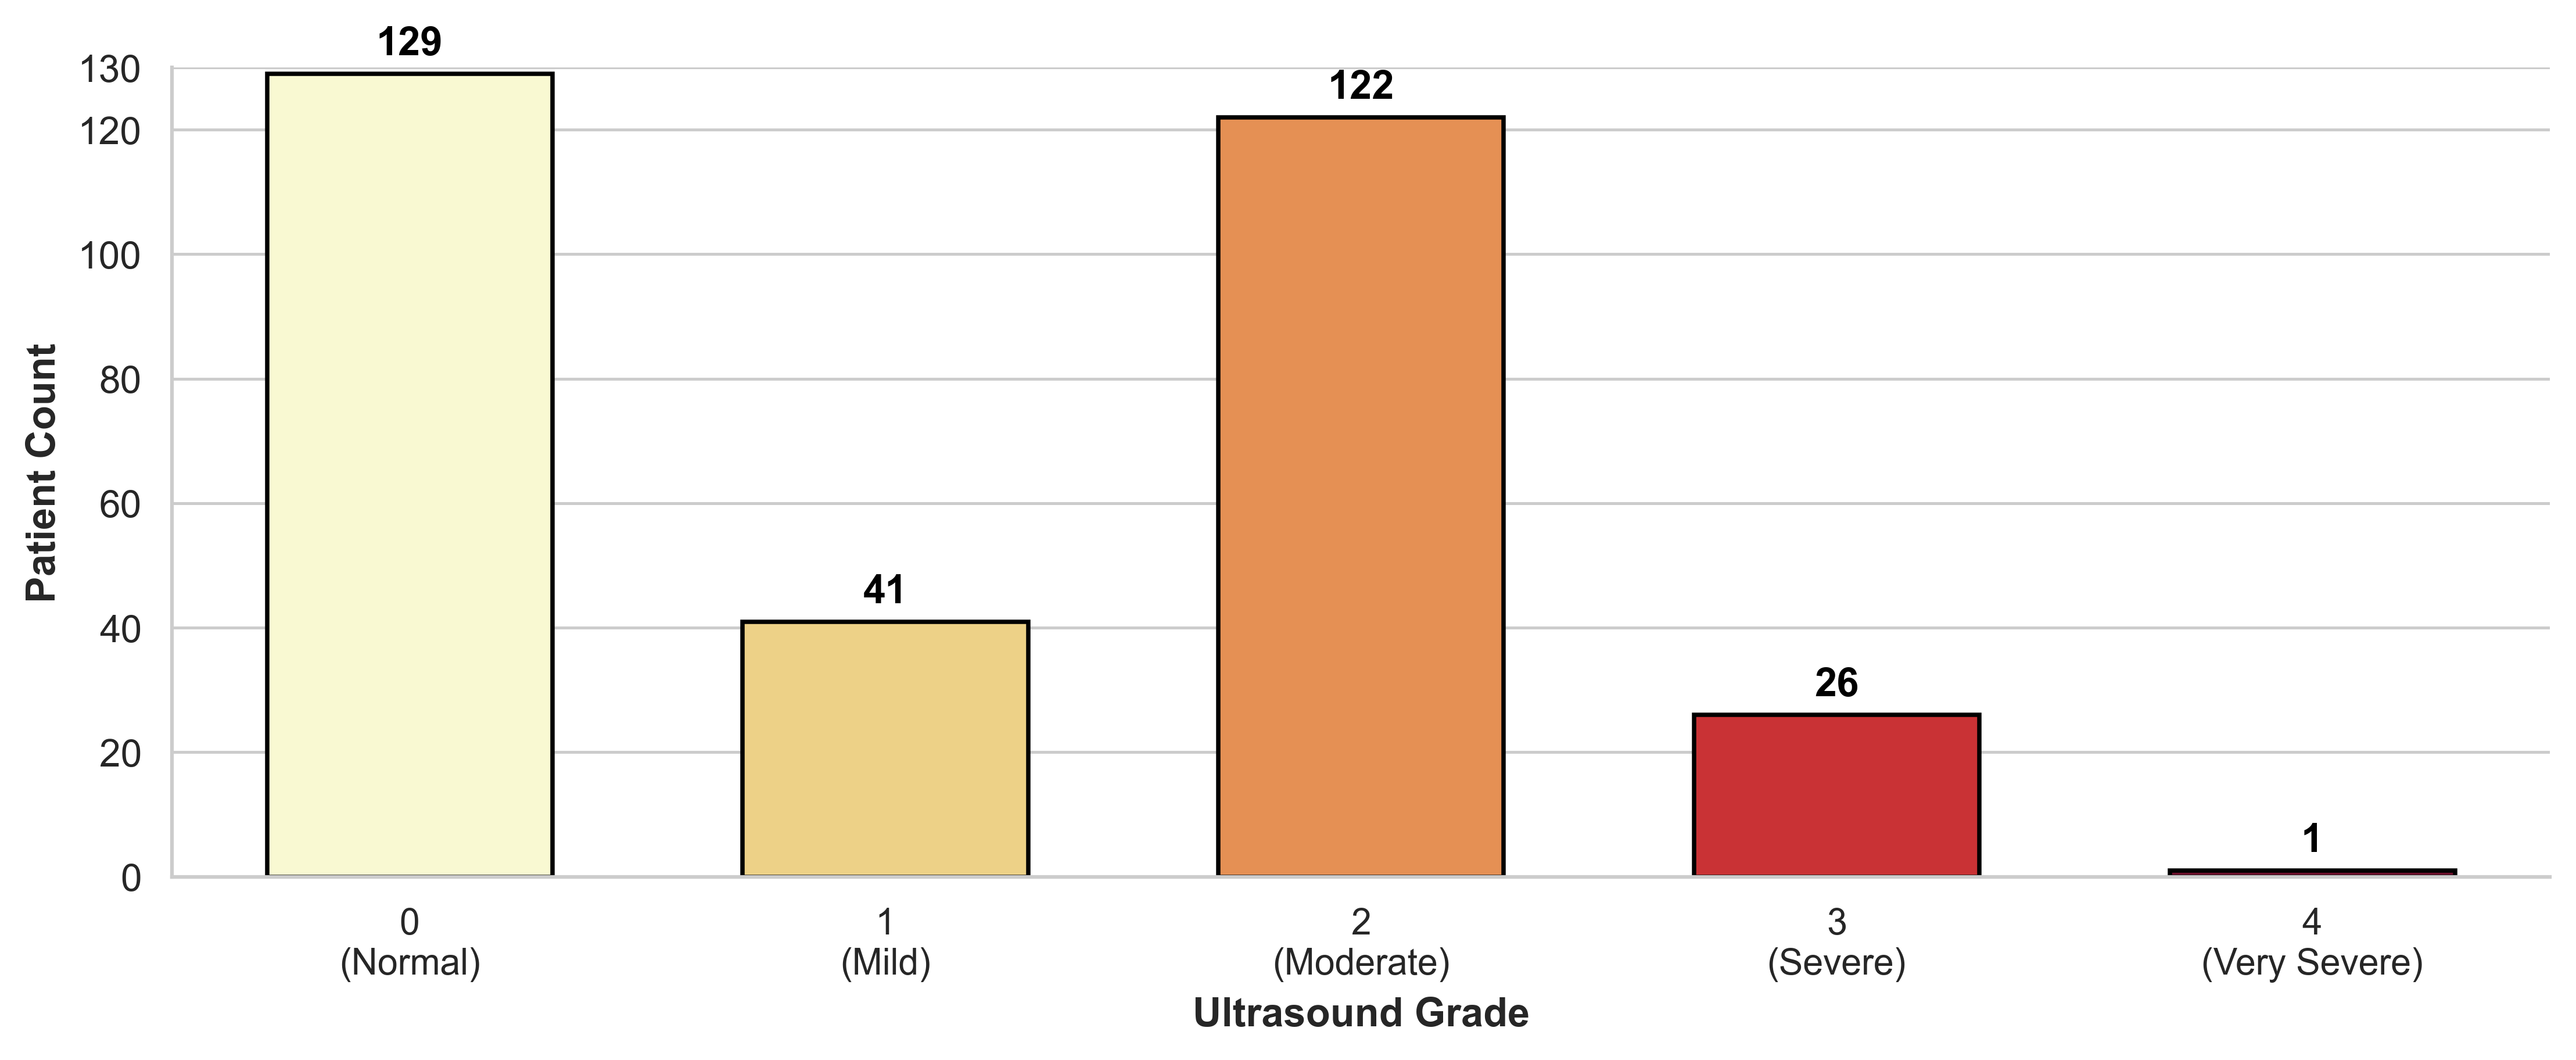

In [12]:
# GROUP 2C: HEPATIC FAT ACCUMULATION (IMAGING)
# Source: Ultrasonography.
# Note: Direct imaging diagnosis, distinct from BIA predictions.
df_hepatic_fat = df[[
    'Hepatic Fat Accumulation (HFA)' # Fatty liver severity (Grades 0-3)
]].copy()
PlottingData.plot_hfa_severity(df_hepatic_fat,title_on=False,is_final_record=True)